In [3]:
%%bash
jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Solution", "Main"]' \
  --output ../exercises/D1-02_linear-regression.ipynb D1-02_linear-regression.ipynb

jupyter nbconvert --to notebook \
  --TagRemovePreprocessor.enabled=True \
  --TagRemovePreprocessor.remove_cell_tags='["Student", "Main"]' \
  --output ../solutions/D1-02_linear-regression.ipynb D1-02_linear-regression.ipynb

[NbConvertApp] Converting notebook D1-02_linear-regression.ipynb to notebook
[NbConvertApp] Writing 90784 bytes to ../exercises/D1-02_linear-regression.ipynb
[NbConvertApp] Converting notebook D1-02_linear-regression.ipynb to notebook
[NbConvertApp] Writing 160226 bytes to ../solutions/D1-02_linear-regression.ipynb


# INFORMATION
In exercises, you should fill the cells with `...`. These cells are placed after **QUESTION** subheadings.

# Problem presentation
In this example, we try to predict the energy consumption used for **cabins and holiday homes** in the NO-5 region of Norway. To do so, we will use different weather variables from the Florida station in Bergen: maximum temperature, maximum wind and precipitation.


![alt text](../../extras/map_of_norge_areas.png "Optional Title")

(photos credits: astrom.no)


# Load python modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib 
import pandas as pd
import xarray as xr
import seaborn as sns
import sklearn

# STEP 1 PREPROCESSING DATA
The first step of the machine learning pipeline is to load the data from a file. Here, our data is stored in the `dataset_energy.csv`. We use the `pandas` library to load the data.

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/rguilcas/BCCR-ML-course/refs/heads/main/lecture_exercises/data/dataset_energy.csv', index_col=0)
df

,Pr,Tmax,Tmin,v_mean,v_max,Consumption Cabins and holiday properties,Consumption Household,Consumption Primary Industry,Consumption Secondary Industry,Consumption Tertiary Service,Consumption Total,hour,dayofyear,month,dayofweek
2020-12-31 23:00:00,0.0,0.6,-0.4,0.9,2.4,83301.548,565464.941,15941.561,1094799.611,281465.947,2040973.608,23,366,12,3
2021-01-01 00:00:00,0.0,-0.3,-0.6,0.2,1.0,81239.060,561738.679,15635.410,1099480.696,281856.955,2039950.800,0,1,1,4
2021-01-01 01:00:00,0.0,-0.4,-1.1,0.7,1.3,78309.658,552567.055,15568.727,1054455.916,282018.246,1982919.602,1,1,1,4
2021-01-01 02:00:00,0.0,-0.6,-1.2,0.6,0.8,75951.558,539974.014,15459.587,1049728.608,283190.286,1964304.053,2,1,1,4
2021-01-01 03:00:00,0.0,-1.0,-1.5,1.5,1.5,75057.689,530039.983,15537.723,1099942.882,284519.093,2005097.370,3,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-16 17:00:00,2.1,13.0,12.9,1.8,1.8,21527.503,368426.508,13442.023,863990.567,422169.360,1689555.961,17,259,9,1
2025-09-16 18:00:00,0.0,12.9,12.8,0.4,2.3,22074.614,382777.219,13315.455,843881.452,345811.055,1607859.795,18,259,9,1
2025-09-16 19:00:00,0.0,12.9,12.4,2.1,2.2,22004.477,381955.358,12774.351,826840.103,292443.352,1536017.641,19,259,9,1
2025-09-16 20:00:00,0.0,12.6,12.4,3.3,3.6,22002.303,362725.748,12505.712,818787.621,273220.806,1489242.190,20,259,9,1


Our dataset contains hourly values from 2020 to 2025.

Once the data is loaded, we need to turn the datasets into an ML friendly array. To do this, we choose the variables necessary for the analysis and then we transform them into numpy arrays.

In [ ]:
X = df[['Pr','Tmin','v_mean','v_max']].values # X is the array containing the data we use to predict the result.
y = df['Consumption Cabins and holiday properties'].values # y is the array representing the values we want to predict.

At this step, some time should usually be used to better prepare the data for the ML framework. We will talk about how to preprocess data later in the course.
Here, we will still split the data into training and validation datasets

## **QUESTION 1**: Create train, validation and test datasets from `X` and `y`.

In [ ]:
X_train, X_valtest, y_train, y_valtest = ...
X_val, X_test, y_val, y_test = ...

In [4]:
X_train, X_valtest, y_train, y_valtest = sklearn.model_selection.train_test_split(X,y, train_size=0.7)
X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(X_valtest,y_valtest, train_size=0.7)

# STEP 2: Define ML model and fit it to the data

Once we have loaded the data, we create an ML model using scikit learn. For this problem, we will use a simple multivariable linear regression.



## Step 2.1: Create model
We start by using scikit-learn built in `LinearRegression` module.

## **QUESTION 2**: Define the model by creating the object `model` in the following cell.

In [ ]:
model = ...

In [5]:
model = sklearn.linear_model.LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Step 2.2: Fit the model to the data
Once we have defined the model, we will fit the model to the data. The model will change some internal coefficients to link the X and Y datasets.

## **QUESTION 3**: Fit the model to the **training data** in the following cell.

In [ ]:
...

In [6]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# STEP 3: Make predictions and evaluate the model skill
Once the model is fitted to the data, we can use it to make predictions.

## Step 3.1: Predict `y` from `X`
We predict the values of `y` from `X` based on the relation learned by the model. 

## **QUESTION 4**: Use the **validation data** to make predictions.

In [ ]:
y_val_predictions = ...

In [7]:
y_val_predictions = model.predict(X_val)

## Step 3.2: Plot the results and evaluate the model.
To visually evaluate the model, we plot the predicted `y` values against the true `y` values.


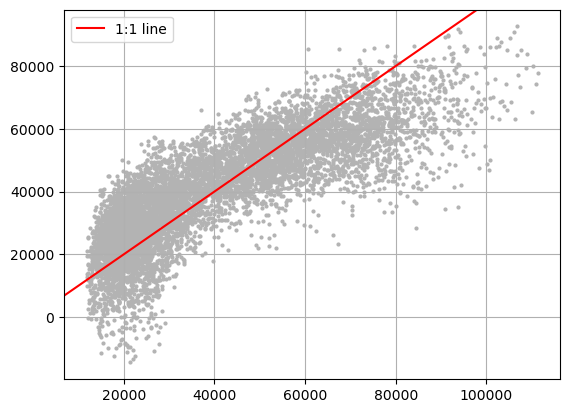

In [8]:
fig, ax = plt.subplots()

ax.scatter(x=y_val, y=y_val_predictions, color='.7', s=4)
ax.axline((y.mean(),y.mean()), slope = 1, color='red', label='1:1 line')
ax.legend()
ax.grid()

We then evaluate model results using two different scores.

## **QUESTION 5**: Evaluate the model with the `r2_score` and the `root_mean_square_error`.

In [ ]:
rmse = ...
r2_score = ...
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

In [10]:
rmse = sklearn.metrics.root_mean_squared_error(y_val, y_val_predictions)
r2_score = sklearn.metrics.r2_score(y_val, y_val_predictions)
print(f"RMSE: {rmse:.02f}")
print(f"R2: {r2_score:.02f}")

RMSE: 11947.78
R2: 0.68
